In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import torch.nn as nn
import pandas as pd
import sentencepiece
from tqdm import tqdm
import comet_ml
import sacrebleu
from torch.utils.data import DataLoader

In [3]:
from dataset import WordTokenizer, TextDataset

In [4]:
train_dataset = TextDataset("data/train.de-en.de", "data/train.de-en.en", min_samples=30)
val_dataset = TextDataset("data/val.de-en.de", "data/val.de-en.en", tokenizers=(train_dataset.tokenizer_de, train_dataset.tokenizer_en))

In [5]:
# train_data, _ = train_test_split(dataset, test_size=0.7)

In [6]:
from model import LanguageModelTransformer

In [7]:
from train import train

In [8]:
train_loader = DataLoader(train_dataset, 256, True, pin_memory=True, num_workers=2)
val_loader = DataLoader(val_dataset, 256, True, pin_memory=True, num_workers=2)

In [12]:
model = LanguageModelTransformer(train_dataset, num_decoder_layers=2, num_encoder_layers=2, dim_feedforward=512, d_model=256, dropout=0.2)
model.to("cuda")      

LanguageModelTransformer(
  (embedding_en): Embedding(6136, 256, padding_idx=0)
  (embedding_de): Embedding(6494, 256, padding_idx=0)
  (trans): Transformer(
    (encoder): TransformerEncoder(
      (layers): ModuleList(
        (0-1): 2 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=256, out_features=256, bias=True)
          )
          (linear1): Linear(in_features=256, out_features=512, bias=True)
          (dropout): Dropout(p=0.2, inplace=False)
          (linear2): Linear(in_features=512, out_features=256, bias=True)
          (norm1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.2, inplace=False)
          (dropout2): Dropout(p=0.2, inplace=False)
        )
      )
      (norm): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
    (decoder): TransformerDecoder(
  

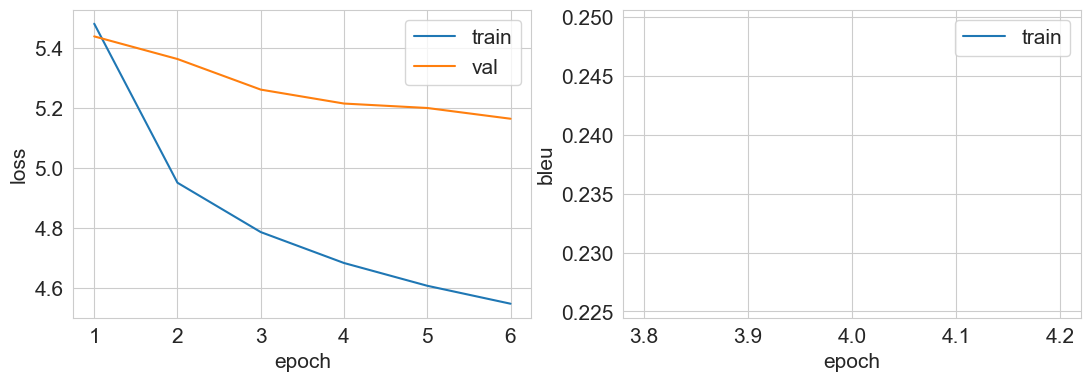

Generation examples:
Doich: nun , für diejenigen von ihnen , die nicht so vertraut mit dem begriff „ autismus " sind ; es ist eine komplexe <unk> des gehirns , die die soziale kommunikation , das lernen und manchmal körperliche fähigkeiten beeinflusst . <eos>                                                                                     
Eng: reading 's first as <unk> as fair dolphin -- <unk> ultimate <unk> <unk> national cylinder <unk> <unk> <unk> joshua <unk> on gestures plants <unk> <unk> , cooling . fortunate actually <unk> have <unk> <unk> <unk> <unk> by the same <unk> tables
_________________________________________________________________________


Training 7/15:  58%|█████▊    | 445/766 [00:46<00:30, 10.57it/s]

In [ ]:
optimizer   = torch.optim.Adam(model.parameters(), 3e-4,  weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, 15)
   
train(model, optimizer, train_loader=train_loader , scheduler=scheduler, val_loader=val_loader, num_epochs=15, bleu_iter=5)

In [ ]:
torch.save(model.state_dict(), "check_lstm.pth")

In [ ]:
cnt = 0
with open("data/test1.de-en.de", "r", encoding="utf-8") as f_in:
    with open("data/test1_lstm.de-en.en", "w", encoding="utf-8") as f_out:
        for line in f_in.readlines():
            new_line = model.inference(line, temp=0.3) 
            if new_line[-1] != "\n":
                new_line += "\n"
            f_out.write(new_line)
            cnt += 1

KeyboardInterrupt: 